# Tech skills study

### Download dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datamatastudios/skill-scarcity-index")

print("Path to dataset files:", path)

100%|██████████| 116k/116k [00:00<00:00, 30.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/datamatastudios/skill-scarcity-index/versions/8


What files are inside the downloaded folder?

In [5]:
import os

os.listdir(path)

['skill-scarcity-index.csv', 'skill-scarcity-index.json']

Create a dataframe using pandas

In [6]:
import pandas as pd

data = pd.read_csv(path + f'/{os.listdir(path)[0]}')
data

,snapshot_date,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
0,2026-07-12,ai,A/B Testing,115,4.7,1.0,3.9,2.0,49.2
1,2026-07-12,ai,Agile / Scrum,63,2.6,1.0,42.5,14.0,62.9
2,2026-07-12,ai,AI Agents,153,6.3,NaN,45.5,5.9,72.0
3,2026-07-12,ai,AI Coding Tools,32,1.3,NaN,NaN,0.0,0.0
4,2026-07-12,ai,Airflow,54,2.2,9.0,-38.7,16.2,57.2
...,...,...,...,...,...,...,...,...,...
3433,2026-07-22,security,System Design,10,0.5,NaN,NaN,0.0,0.0
3434,2026-07-22,security,TensorFlow,10,0.5,61.0,NaN,0.0,46.2
3435,2026-07-22,security,Terraform,117,6.2,0.0,67.2,22.2,43.0
3436,2026-07-22,security,TypeScript,37,2.0,75.0,NaN,0.0,60.0


**Columns**:
- *demand_count*: Active listings mentioning the skill on the snapshot date.
- *demand_pct*: demand_count as a percentage of all active listings in the category.
- *median_days_open*: Median days recently-closed listings with this skill stayed open. Blank below the sample floor.
- *salary_premium_pct*: Median disclosed salary of listings with this skill vs the category median, in percent. Blank below the sample floor.
- *repost_rate_pct*: Share of this skill's listings that are re-posts of an earlier identical role (a failed-hire signal).
- *scarcity_score*: 0-100 weighted percentile-rank composite within the category. Higher = harder to hire.

List of categories

In [22]:
categories = data['category'].unique().tolist()
categories

['ai', 'data', 'devops', 'engineering', 'product', 'security']

### Find the most demanded skill

In [82]:
category = 'ai'

In [121]:
def get_most_avg_demanded_skills(category):
    data2 = data[data['category'] == category]
    data3 = data2.sort_values('demand_count', ascending=False)[['snapshot_date', 'skill_name', 'demand_count']]
    data4 = data3.groupby('skill_name').apply(lambda x: x['demand_count'].mean()).sort_values(ascending=False)[:20].reset_index().rename(columns={'skill_name': 'skill', 0: 'avg_demand_count'})
    return data4

In [169]:
get_most_avg_demanded_skills(category)

,skill,avg_demand_count
0,Machine Learning,1881.250
1,LLMs / GenAI,1115.250
2,Python,641.125
3,AI Agents,304.750
4,PyTorch,288.125
5,Stakeholder Mgmt,267.625
6,AWS,263.625
7,RAG,250.375
8,Azure,232.750
9,Deep Learning,210.875


Ignore warnings

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

Visualizing the data

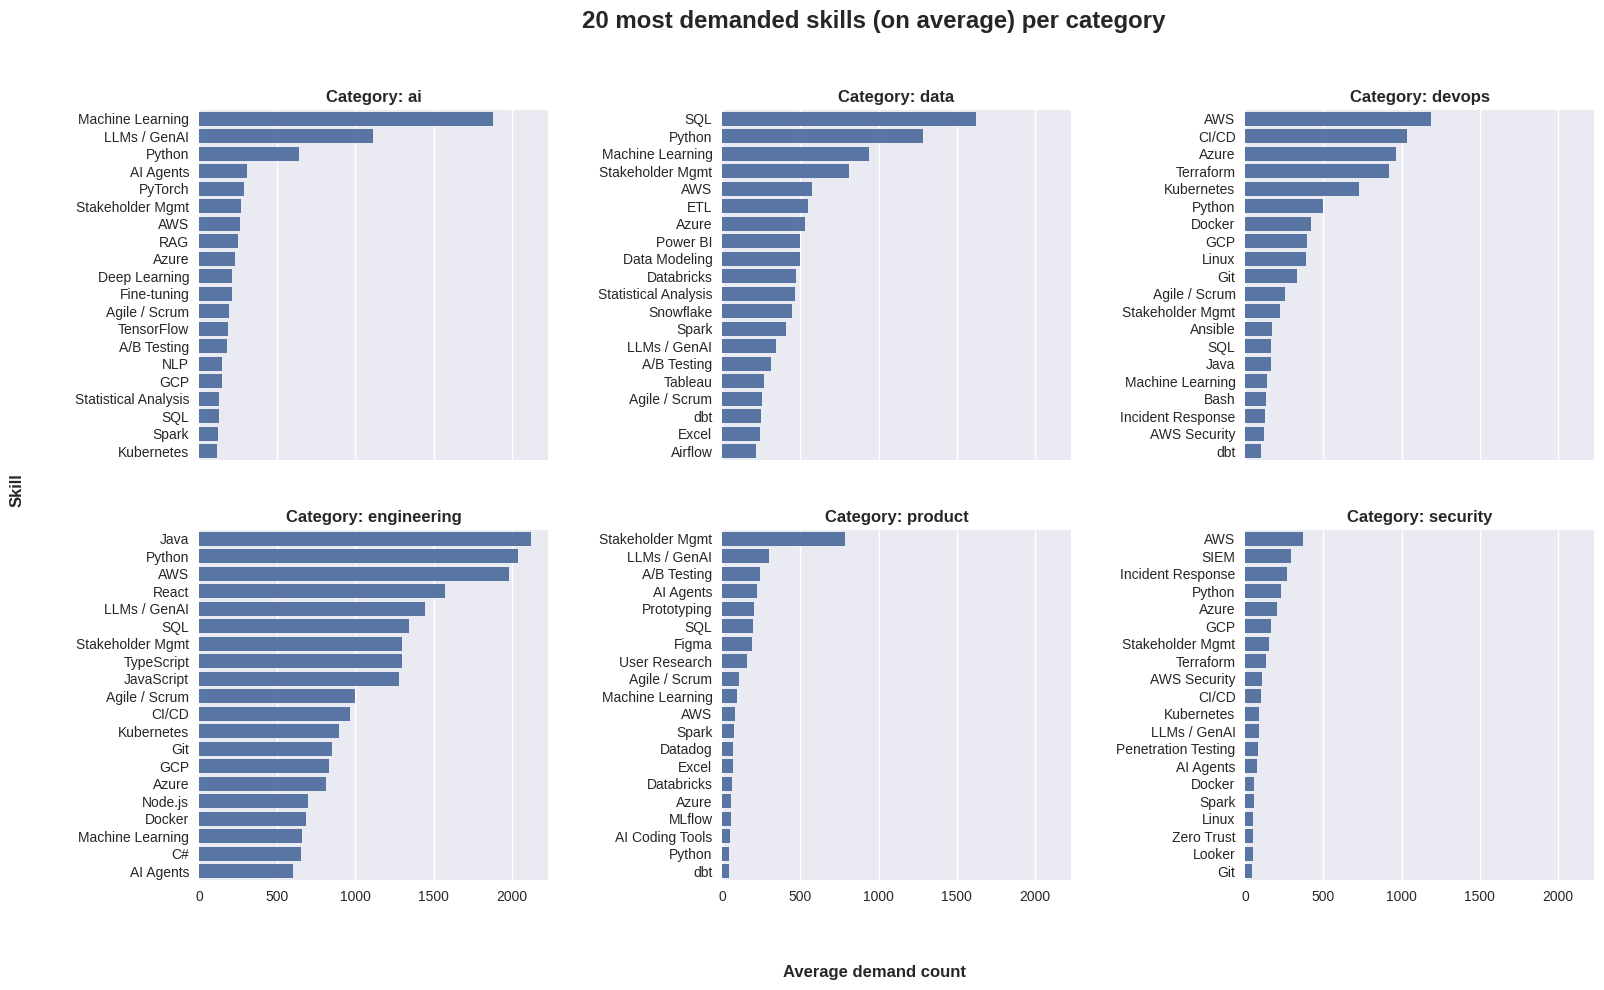

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

fig, axes = plt.subplots(2,3, figsize=(18,10), sharex=True)
fig.subplots_adjust(wspace=0.5, hspace=0.2)
fig.suptitle('20 most demanded skills (on average) per category', fontsize='xx-large', fontweight='heavy')
fig.supxlabel('Average demand count', fontweight='bold')
fig.supylabel('Skill', fontweight='bold')

x_counter = 0
y_counter = 0
for c in categories:
    sns.barplot(ax=axes[y_counter,x_counter], data=get_most_avg_demanded_skills(c), y='skill', x='avg_demand_count')
    axes[y_counter,x_counter].set_title(f'Category: {c}', fontweight='bold')
    axes[y_counter,x_counter].set_xlabel("")
    axes[y_counter,x_counter].set_ylabel("")
    x_counter += 1
    if x_counter >= 3:
        x_counter = 0
        y_counter = 1

fig.show()



Stakeholder Mgmt appears in every category. **What is it?**: Stakeholder management is the continuous process of identifying, analyzing, and engaging people or groups who can affect or be affected by a project

**AI**: PyTorch is the most demanded library and AWS and Azure are the most demanded cloud computing platforms. LLMs, GenAI and Agentic AI are the most demanded AI fields and Python is the language to know.

GCP is mentioned across many categories. **What is it?**: Google Cloud Platform.

### Find the best paid skill

In [167]:
def get_best_avg_paid_skills(category):
    data2 = data[data['category'] == category]
    data3 = data2.sort_values('salary_premium_pct', ascending=False)[['snapshot_date', 'skill_name', 'salary_premium_pct']]
    data4 = data3.groupby('skill_name').apply(lambda x: x['salary_premium_pct'].mean()).sort_values(ascending=False)[:20].reset_index().rename(columns={'skill_name': 'skill', 0: 'avg_salary_premium_pct'})
    return data4

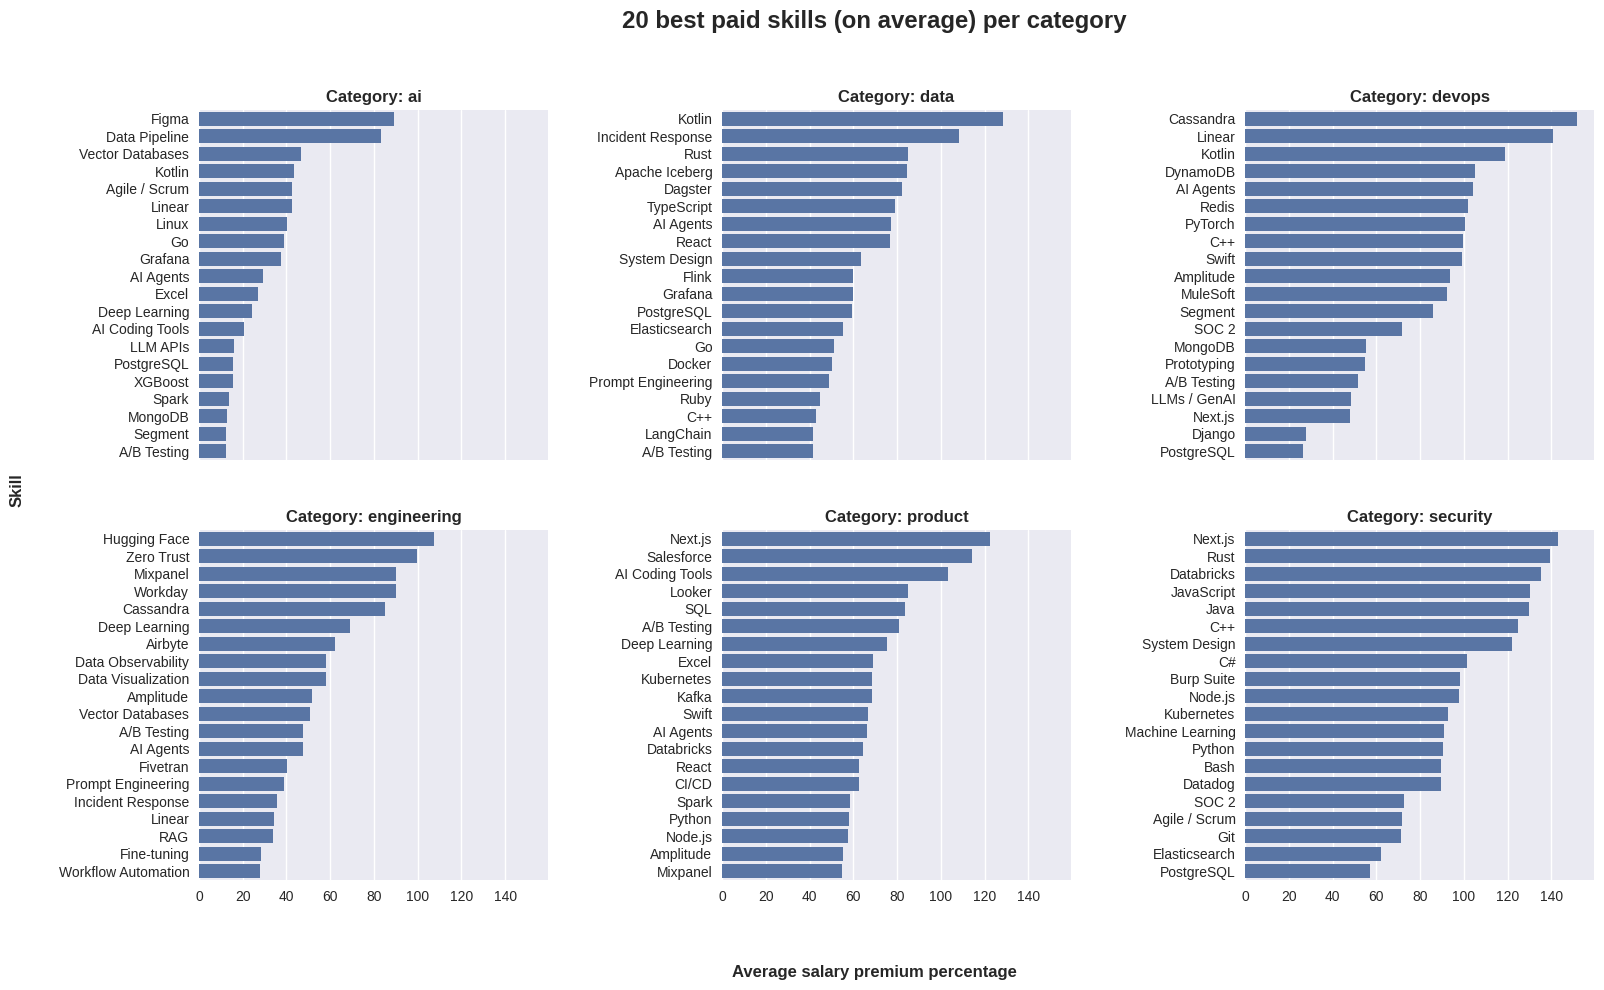

In [168]:
fig, axes = plt.subplots(2,3, figsize=(18,10), sharex=True)
fig.subplots_adjust(wspace=0.5, hspace=0.2)
fig.suptitle('20 best paid skills (on average) per category', fontsize='xx-large', fontweight='heavy')
fig.supxlabel('Average salary premium percentage', fontweight='bold')
fig.supylabel('Skill', fontweight='bold')

x_counter = 0
y_counter = 0
for c in categories:
    sns.barplot(ax=axes[y_counter,x_counter], data=get_best_avg_paid_skills(c), y='skill', x='avg_salary_premium_pct')
    axes[y_counter,x_counter].set_title(f'Category: {c}', fontweight='bold')
    axes[y_counter,x_counter].set_xlabel("")
    axes[y_counter,x_counter].set_ylabel("")
    x_counter += 1
    if x_counter >= 3:
        x_counter = 0
        y_counter = 1

fig.show()

Kotlin is in the top skills of AI and data. **What is it?**: Kotlin is a modern, cross-platform programming language known for being concise, safe, and fully interoperable with Java. It is widely used for Android development, server-side programming, and cross-platform app sharing.

**AI**: Figma is the top salary premium skill. Linear is the sixth. **What is it?**: A high-performance issue tracking and project management tool built for software development teams. Data pipeline is the second.

### Find the most scarce skill

In [171]:
def get_most_avg_scarce_skills(category):
    data2 = data[data['category'] == category]
    data3 = data2.sort_values('scarcity_score', ascending=False)[['snapshot_date', 'skill_name', 'scarcity_score']]
    data4 = data3.groupby('skill_name').apply(lambda x: x['scarcity_score'].mean()).sort_values(ascending=False)[:20].reset_index().rename(columns={'skill_name': 'skill', 0: 'avg_scarcity_score'})
    return data4

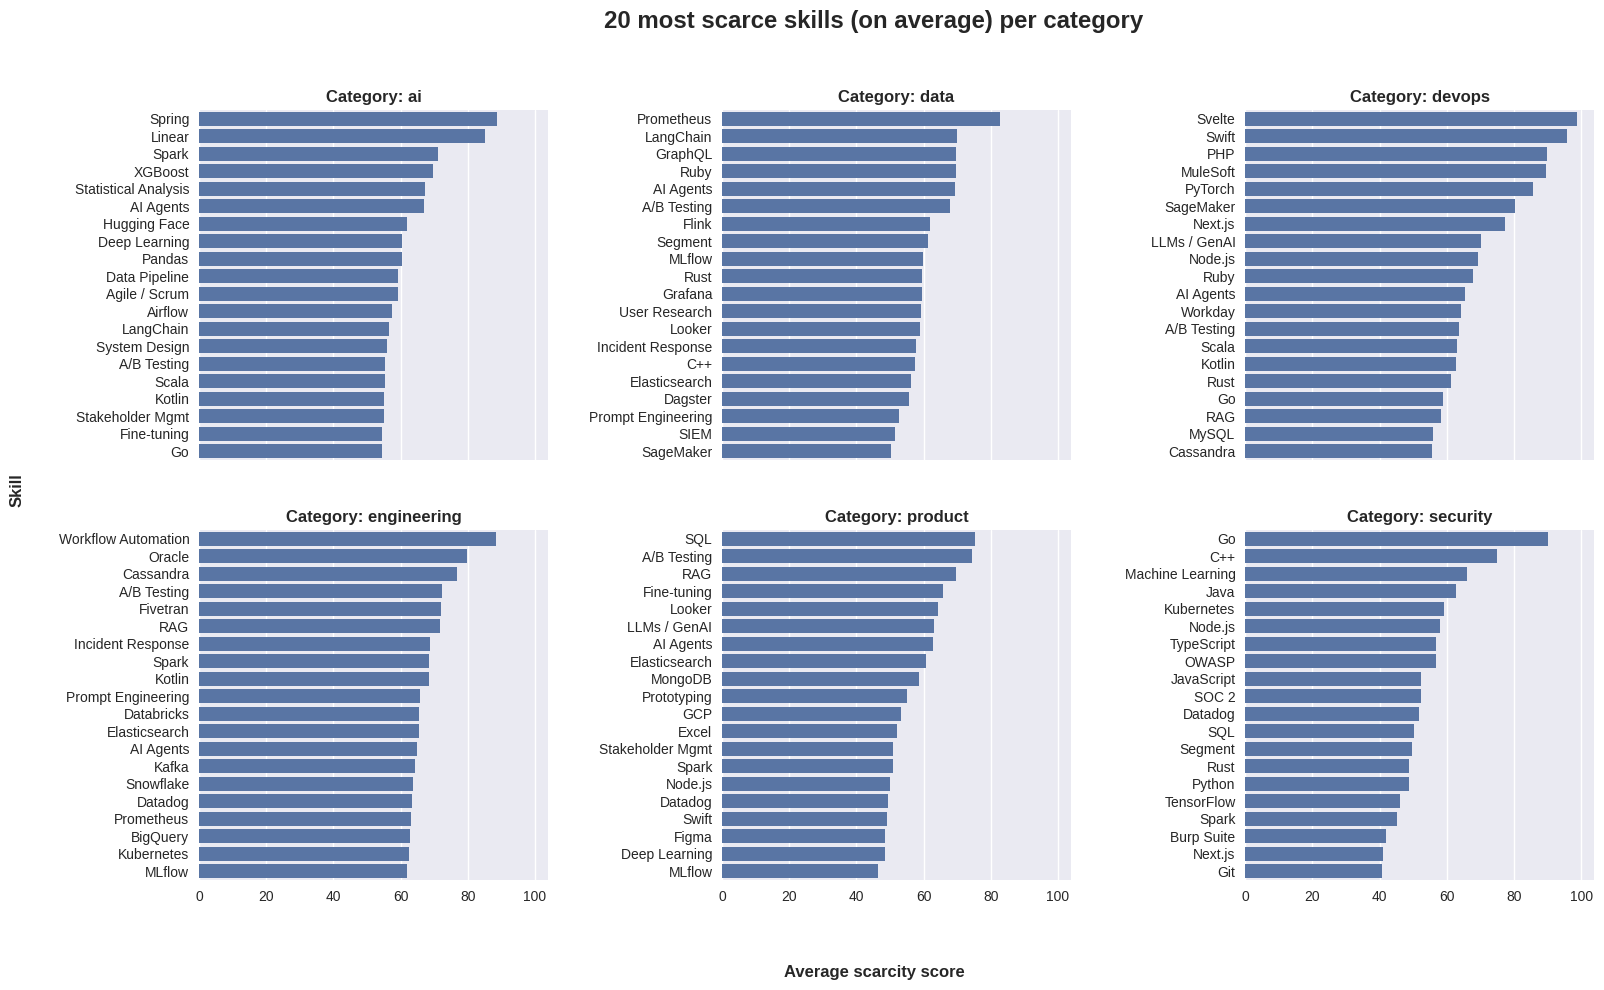

In [173]:
fig, axes = plt.subplots(2,3, figsize=(18,10), sharex=True)
fig.subplots_adjust(wspace=0.5, hspace=0.2)
fig.suptitle('20 most scarce skills (on average) per category', fontsize='xx-large', fontweight='heavy')
fig.supxlabel('Average scarcity score', fontweight='bold')
fig.supylabel('Skill', fontweight='bold')

x_counter = 0
y_counter = 0
for c in categories:
    sns.barplot(ax=axes[y_counter,x_counter], data=get_most_avg_scarce_skills(c), y='skill', x='avg_scarcity_score')
    axes[y_counter,x_counter].set_title(f'Category: {c}', fontweight='bold')
    axes[y_counter,x_counter].set_xlabel("")
    axes[y_counter,x_counter].set_ylabel("")
    x_counter += 1
    if x_counter >= 3:
        x_counter = 0
        y_counter = 1

fig.show()

We find some interesting information here. 

In **AI**, Linear and Kotlin are scarce and very well paid. Spring is also mentioned. **What is it?**: Spring in technology is a popular open-source framework for building Java enterprise applications. Spark, AI Agents, XGBoost, Deep Learning, Pandas... are mentioned.

### Give ratings to skills based on attributes

In [186]:
data2 = data[data['category'] == category][['skill_name', 'demand_count', 'salary_premium_pct','scarcity_score']]
data3 = data2.groupby('skill_name').agg('mean').reset_index().dropna()
data3

,skill_name,demand_count,salary_premium_pct,scarcity_score
0,A/B Testing,177.875,12.187500,55.4125
1,AI Agents,304.750,29.462500,66.9750
2,AI Coding Tools,32.125,20.585714,42.8875
3,AWS,263.625,-24.275000,29.7625
4,AWS Security,10.000,-9.900000,18.4000
...,...,...,...,...
83,Vector Databases,15.600,46.700000,25.2600
85,Workday,11.500,-55.500000,1.0500
86,XGBoost,38.375,15.425000,69.7375
87,scikit-learn,79.625,-46.025000,31.1625


Give a rating to each attribute using percentiles.

In [218]:
rating_labels = range(1, 101)

for col in ['demand_count', 'salary_premium_pct', 'scarcity_score']:
    data3[f'{col}_rating'] = pd.qcut(data3[col].rank(method='first'), q=100, labels=rating_labels)

data3

,skill_name,demand_count,salary_premium_pct,scarcity_score,demand_count_rating,salary_premium_pct_rating,scarcity_score_rating
0,A/B Testing,177.875,12.187500,55.4125,83,75,83
1,AI Agents,304.750,29.462500,66.9750,97,89,95
2,AI Coding Tools,32.125,20.585714,42.8875,40,85,56
3,AWS,263.625,-24.275000,29.7625,93,25,20
4,AWS Security,10.000,-9.900000,18.4000,1,49,3
...,...,...,...,...,...,...,...
83,Vector Databases,15.600,46.700000,25.2600,14,98,10
85,Workday,11.500,-55.500000,1.0500,6,2,1
86,XGBoost,38.375,15.425000,69.7375,48,81,98
87,scikit-learn,79.625,-46.025000,31.1625,66,6,25


Compute a global rating based on different weights:
- *demand_count_rating*: 0.25
- *salary_premium_pct_rating*: 0.4
- *scarcity_score_rating*: 0.35

In [225]:
data3['rating'] = 0.25*data3['demand_count_rating'].astype(float) + 0.4*data3['salary_premium_pct_rating'].astype(float) + 0.35*data3['scarcity_score_rating'].astype(float)
skills = data3[['skill_name', 'rating']].sort_values(by='rating', ascending=False)
skills

,skill_name,rating
1,AI Agents,93.10
5,Agile / Scrum,90.65
19,Deep Learning,89.20
75,Spark,85.50
78,Statistical Analysis,81.30
...,...,...
4,AWS Security,20.90
54,NumPy,15.75
11,C#,14.85
23,ETL,8.85


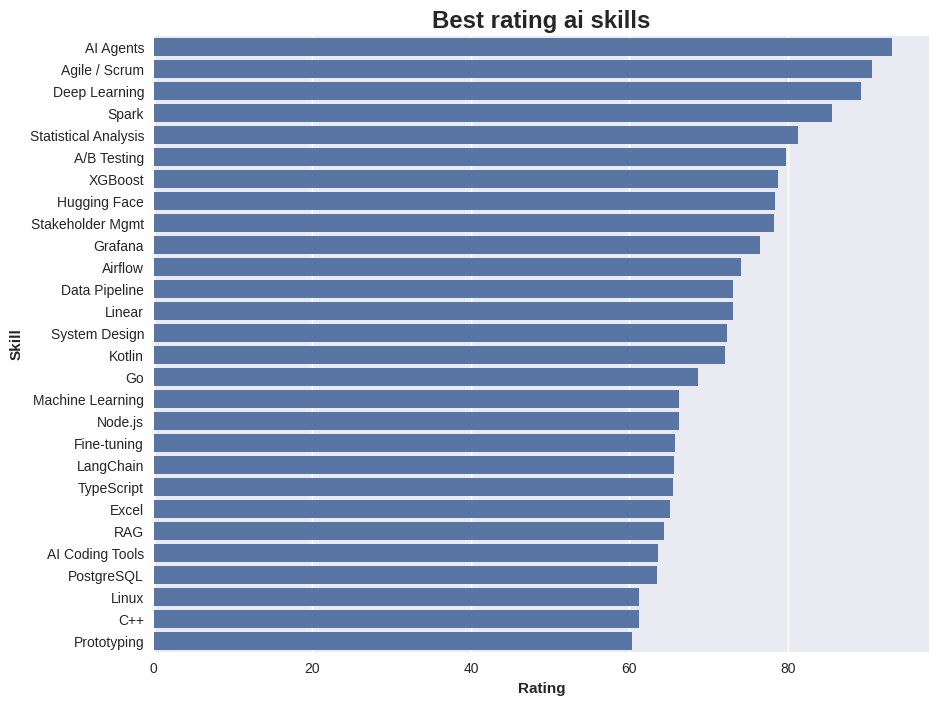

In [239]:
fig = plt.figure(figsize=(10,8))
plt.title(f'Best rating {category} skills', fontsize='xx-large', fontweight='heavy')
sns.barplot(skills[skills['rating'] > 60], x='rating', y='skill_name')
plt.xlabel('Rating', fontweight='heavy')
plt.ylabel('Skill', fontweight='heavy')
fig.show()